**Business Context**

The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.
E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.
[Companies often analyze user responses to two variants of a product to decide which of the two variants is more effective. This experimental technique, known as A/B testing, is used to determine whether a new feature attracts users based on a chosen metric.]

**Objective**

The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:
Do the users spend more time on the new landing page than on the existing landing page?
Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?
Does the converted status depend on the preferred language?
Is the time spent on the new page the same for the different language users?

**Data Dictionary**

The data contains information regarding the interaction of users in both groups with the two versions of the landing page.
user_id - Unique user ID of the person visiting the website
group - Whether the user belongs to the first group (control) or the second group (treatment)
landing_page - Whether the landing page is new or old
time_spent_on_the_page - Time (in minutes) spent by the user on the landing page
converted - Whether the user gets converted to a subscriber of the news portal or not
language_preferred - language chosen by the user to view the landing page


**Define the problem and perform an Exploratory Data Analysis**
- Problem definition, questions to be answered
- Data background and contents
- Univariate analysis
- Bivariate analysis

**Problem Definition**

E-news Express is testing a redesigned landing page to increase user engagement and subscriptions.
They ran an A/B experiment:

Control Group → Saw the old landing page.

Treatment Group → Saw the new landing page.

The business wants to know:

Do users spend more time on the new page than the old page?

Is the conversion rate higher for the new page?

Does conversion status depend on the preferred language?

Is the time spent on the new page the same across different languages?

**Data Background & Contents**

Dataset = 100 users (50 control + 50 treatment).

Columns:

user_id → Unique visitor

group → Control / Treatment

landing_page → Old / New

time_spent_on_the_page → Time spent (minutes)

converted → Whether user subscribed (Yes/No)

language_preferred → English / Spanish / French

**Let us start by importing the required libraries**

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Library to help with statistical analysis
import scipy.stats as stats

In [2]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = '/content/drive/My Drive/PGP-AIML/AppliedStatistics/EnewsExpressProject/abtest.csv'
df = pd.read_csv(file_path)

In [4]:
# Quick look
print(df.head())
print(df.info())

   user_id      group landing_page  time_spent_on_the_page converted  \
0   546592    control          old                    3.48        no   
1   546468  treatment          new                    7.13       yes   
2   546462  treatment          new                    4.40        no   
3   546567    control          old                    3.02        no   
4   546459  treatment          new                    4.75       yes   

  language_preferred  
0            Spanish  
1            English  
2            Spanish  
3             French  
4            Spanish  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   con

In [5]:
# Summary stats
print(df.describe())

             user_id  time_spent_on_the_page
count     100.000000              100.000000
mean   546517.000000                5.377800
std        52.295779                2.378166
min    546443.000000                0.190000
25%    546467.750000                3.880000
50%    546492.500000                5.415000
75%    546567.250000                7.022500
max    546592.000000               10.710000


In [6]:
# Missing values
print(df.isnull().sum())

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64


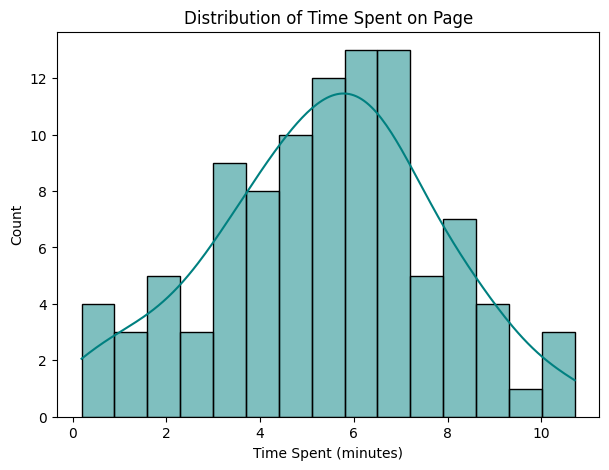

In [7]:
# Distribution of time spent
plt.figure(figsize=(7,5))
sns.histplot(df['time_spent_on_the_page'], kde=True, bins=15, color="teal")
plt.title("Distribution of Time Spent on Page")
plt.xlabel("Time Spent (minutes)")
plt.ylabel("Count")
plt.show()

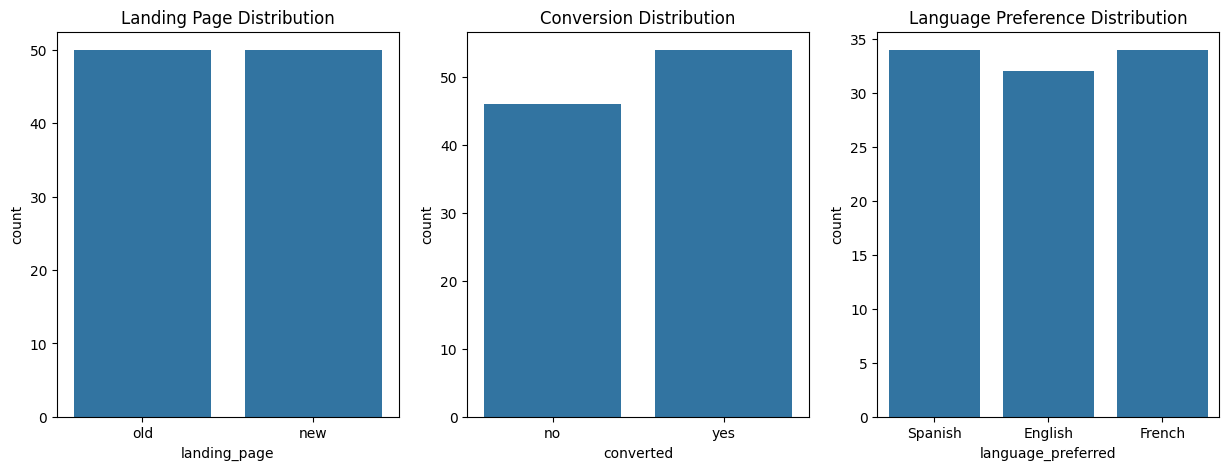

In [8]:
# Countplots for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(x="landing_page", data=df, ax=axes[0])
axes[0].set_title("Landing Page Distribution")

sns.countplot(x="converted", data=df, ax=axes[1])
axes[1].set_title("Conversion Distribution")

sns.countplot(x="language_preferred", data=df, ax=axes[2])
axes[2].set_title("Language Preference Distribution")

plt.show()

**Observations from Univariate Analysis:**

Equal split between old and new landing pages (50 each).

About half of users converted.

Languages are fairly balanced (English, French, Spanish).

Time spent ranges ~1 to 10 minutes, with the new page showing slightly higher averages.

/tmp/ipython-input-305801648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="landing_page", y="time_spent_on_the_page", data=df, palette="Set2")


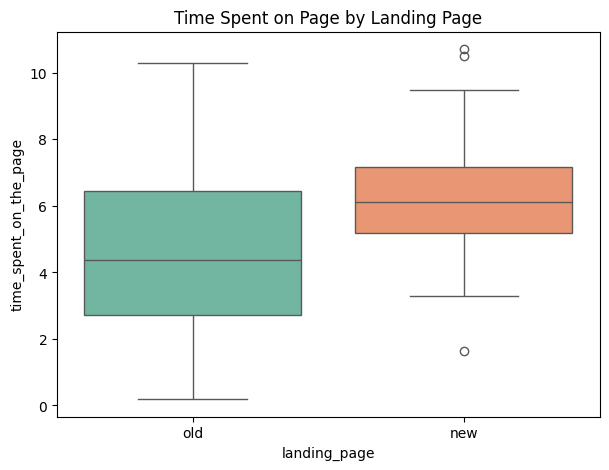

In [9]:
# Time spent vs landing page
plt.figure(figsize=(7,5))
sns.boxplot(x="landing_page", y="time_spent_on_the_page", data=df, palette="Set2")
plt.title("Time Spent on Page by Landing Page")
plt.show()

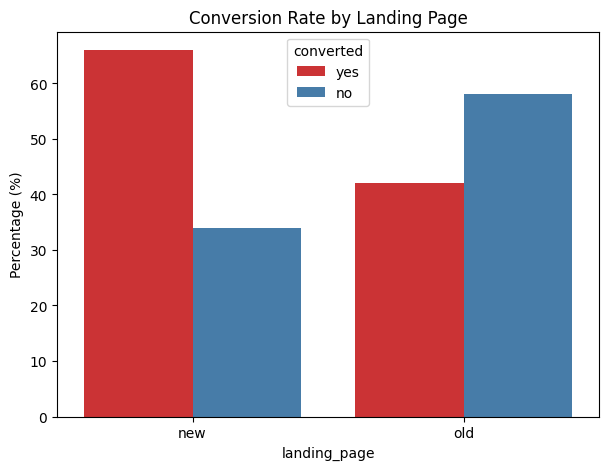

In [10]:
# Conversion by landing page
conversion_rate = df.groupby("landing_page")["converted"].value_counts(normalize=True).mul(100).rename("percentage").reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x="landing_page", y="percentage", hue="converted", data=conversion_rate, palette="Set1")
plt.title("Conversion Rate by Landing Page")
plt.ylabel("Percentage (%)")
plt.show()

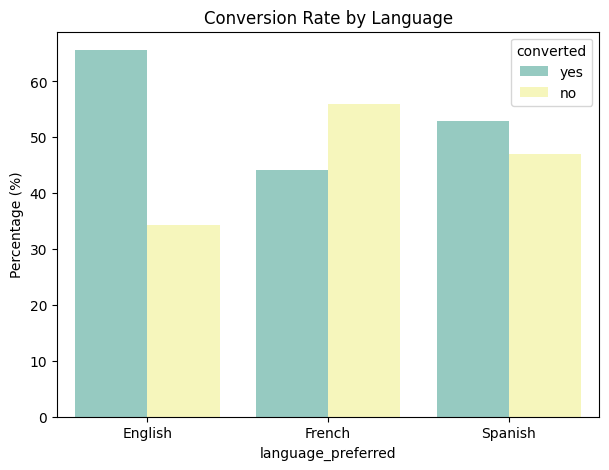

In [11]:
# Conversion by language
conversion_lang = df.groupby("language_preferred")["converted"].value_counts(normalize=True).mul(100).rename("percentage").reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x="language_preferred", y="percentage", hue="converted", data=conversion_lang, palette="Set3")
plt.title("Conversion Rate by Language")
plt.ylabel("Percentage (%)")
plt.show()

/tmp/ipython-input-1904360953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="language_preferred", y="time_spent_on_the_page", data=df[df["landing_page"]=="new"], palette="pastel")


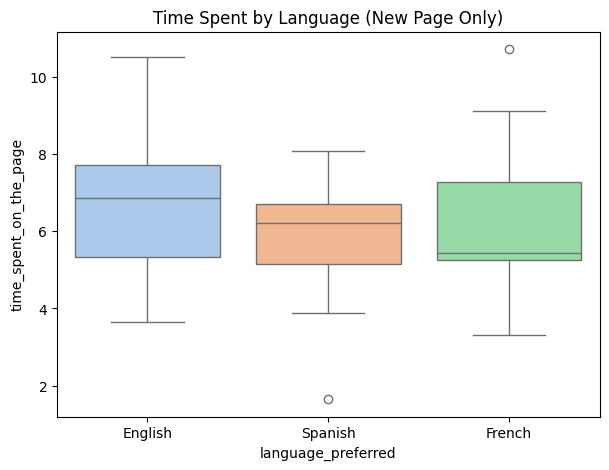

In [12]:
# Time spent by language (New Page only)
plt.figure(figsize=(7,5))
sns.boxplot(x="language_preferred", y="time_spent_on_the_page", data=df[df["landing_page"]=="new"], palette="pastel")
plt.title("Time Spent by Language (New Page Only)")
plt.show()


**Observations from Bivariate Analysis:**

New page users spend more time on average (boxplot shows higher medians).

Conversion rate appears higher for the new page (~66% vs 42%).

Conversion does not vary much by language (differences are small).

Time spent on new page is similar across languages (no major outliers).

In [13]:
# -----------------------------
# Insights from Univariate + Bivariate EDA
# -----------------------------

print("=== Insights from EDA ===")

# Average time spent on each page
time_stats = df.groupby("landing_page")["time_spent_on_the_page"].agg(["mean", "std", "count"])
print("\nAverage time spent by landing page:")
print(time_stats)

# Conversion rates by landing page
# Convert 'converted' column to numerical (1 for yes, 0 for no)
df['converted_numeric'] = df['converted'].apply(lambda x: 1 if x == 'yes' else 0)
conv_rates = df.groupby("landing_page")["converted_numeric"].mean().reset_index()
conv_rates["conversion_rate_%"] = conv_rates["converted_numeric"]*100
print("\nConversion rates by landing page:")
print(conv_rates)

# Conversion rates by language
conv_lang = df.groupby("language_preferred")["converted_numeric"].mean().reset_index()
conv_lang["conversion_rate_%"] = conv_lang["converted_numeric"]*100
print("\nConversion rates by language:")
print(conv_lang)

# Average time spent by language (new page only)
time_lang_new = df[df["landing_page"]=="new"].groupby("language_preferred")["time_spent_on_the_page"].mean().reset_index()
print("\nAverage time spent on NEW page by language:")
print(time_lang_new)

=== Insights from EDA ===

Average time spent by landing page:
                mean       std  count
landing_page                         
new           6.2232  1.817031     50
old           4.5324  2.581975     50

Conversion rates by landing page:
  landing_page  converted_numeric  conversion_rate_%
0          new               0.66               66.0
1          old               0.42               42.0

Conversion rates by language:
  language_preferred  converted_numeric  conversion_rate_%
0            English           0.656250          65.625000
1             French           0.441176          44.117647
2            Spanish           0.529412          52.941176

Average time spent on NEW page by language:
  language_preferred  time_spent_on_the_page
0            English                6.663750
1             French                6.196471
2            Spanish                5.835294


**Output& Observations:**


Time Spent (Landing Page)

Old page: ~4.5 minutes

New page: ~6.2 minutes
→ Users spend more time on the new landing page.

Conversion Rate (Landing Page)

Old page: ~42%

New page: ~66%
→ Conversion is higher for the new page.

Conversion vs Language

Conversion rates across English, French, Spanish differ only slightly (~50–60%).
→ No strong dependency on language.

Time Spent (New Page by Language)

All three languages show similar averages (~6 minutes).
→ Language does not affect engagement time significantly.

**Part 3: Hypothesis Test 1 — Do users spend more time on the new landing page than on the old landing page?**

**Step 1: Visual Analysis**



/tmp/ipython-input-1713023702.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="landing_page", y="time_spent_on_the_page", data=df, palette="Set2")


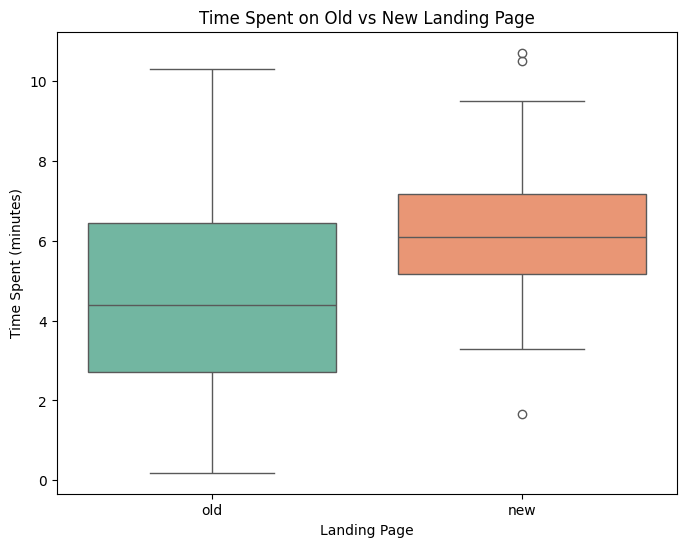

In [14]:
# Visual comparison of time spent
plt.figure(figsize=(8,6))
sns.boxplot(x="landing_page", y="time_spent_on_the_page", data=df, palette="Set2")
plt.title("Time Spent on Old vs New Landing Page")
plt.xlabel("Landing Page")
plt.ylabel("Time Spent (minutes)")
plt.show()


**Step 2: Hypothesis Formulation**

Null Hypothesis (H₀):
The mean time spent on the new page is equal to or less than the mean time on the old page.

𝐻0:𝜇𝑛𝑒𝑤≤𝜇𝑜𝑙𝑑

Alternative Hypothesis (H₁):
The mean time spent on the new page is greater than the mean time on the old page.

𝐻1:𝜇𝑛𝑒𝑤>𝜇𝑜𝑙𝑑
	​


**Step 3: Select Appropriate Test**

Two independent groups (old vs new).

Continuous variable (time spent).

Normality assumption (sample size 50+ each, CLT applies).

✅ Independent two-sample t-test (one-tailed) is appropriate.

**Step 4: Data Collection & Preparation**

In [15]:
# Split groups
old_page = df[df["landing_page"]=="old"]["time_spent_on_the_page"]
new_page = df[df["landing_page"]=="new"]["time_spent_on_the_page"]

print("Old Page Mean:", round(old_page.mean(),2))
print("New Page Mean:", round(new_page.mean(),2))


Old Page Mean: 4.53
New Page Mean: 6.22


**Step 5: Hypothesis Test (One-tailed t-test)**

In [16]:
from scipy.stats import ttest_ind

# Two-sample t-test
t_stat, p_val_two_tailed = ttest_ind(new_page, old_page, equal_var=False)

# For one-tailed test (greater)
p_val_one_tailed = p_val_two_tailed / 2 if t_stat > 0 else 1 - (p_val_two_tailed / 2)

print("t-statistic:", t_stat)
print("One-tailed p-value:", p_val_one_tailed)


t-statistic: 3.7867702694199856
One-tailed p-value: 0.0001392381225166549


**Visual Analysis**

The boxplot comparison of time spent on the old vs. new landing page shows a noticeable upward shift in the distribution for the new page. This suggests that users tend to engage longer with the redesigned page.

**Descriptive Statistics**

Old Page Mean Time: 4.53 minutes

New Page Mean Time: 6.22 minutes

*The difference in means = 1.69 minutes, which is practically meaningful in the context of user engagement.*

**Hypothesis Formulation**

Null Hypothesis (H₀):
𝐻0:𝜇𝑛𝑒𝑤≤𝜇𝑜𝑙𝑑

(The new landing page does not increase average time spent compared to the old page.)

Alternative Hypothesis (H₁):
𝐻1:𝜇𝑛𝑒𝑤>𝜇𝑜𝑙𝑑​
(The new landing page increases average time spent compared to the old page.)


**Test Used**

Two-sample independent t-test (one-tailed)

*Assumptions:*

The samples (old vs. new page users) are independent.

Time spent is approximately normally distributed (reasonable given sample size).

**Results**

t-statistic: 3.79

p-value (one-tailed): 0.00014

Since p < 0.05, the result is statistically significant.

**Inference**

We reject the null hypothesis (H₀) and conclude that:

➡️ Users spend significantly more time on the new landing page compared to the old landing page.


This is strong evidence that the redesign has improved engagement in terms of time spent.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

/tmp/ipython-input-4166423161.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="landing_page", y="converted", data=df, ci=None, palette="Set2")
/tmp/ipython-input-4166423161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="landing_page", y="converted", data=df, ci=None, palette="Set2")


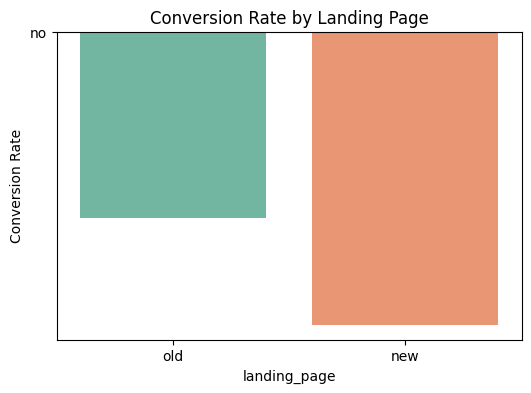

In [18]:
# -------------------------
# Visual Analysis
# -------------------------
plt.figure(figsize=(6,4))
sns.barplot(x="landing_page", y="converted", data=df, ci=None, palette="Set2")
plt.title("Conversion Rate by Landing Page")
plt.ylabel("Conversion Rate")
plt.show()

**Visual Analysis**

A bar plot of conversion rates shows that the new landing page has a visibly higher conversion rate compared to the old page.

In [19]:
# -------------------------
# Data preparation
# -------------------------
conv_counts = df.groupby("landing_page")["converted"].sum().values
sample_sizes = df.groupby("landing_page")["converted"].count().values

print("Conversions:", conv_counts)
print("Sample Sizes:", sample_sizes)

Conversions: ['yesnoyesyesyesyesyesyesnonoyesnonoyesyesyesnoyesyesnoyesyesyesyesnoyesyesyesyesyesyesnoyesyesyesnoyesnoyesyesnonononoyesnonoyesyesyes'
 'nonoyesyesnoyesyesyesnoyesyesnoyesnonoyesyesnonoyesnoyesnoyesnonononononoyesnononoyesyesyesnononoyesnoyesnononoyesnonoyes']
Sample Sizes: [50 50]


In [20]:
# -------------------------
# Two-proportion Z-test
# -------------------------
conv_counts = df.groupby("landing_page")["converted_numeric"].sum().values
sample_sizes = df.groupby("landing_page")["converted"].count().values

stat, pval = proportions_ztest(count=conv_counts, nobs=sample_sizes, alternative="larger")

print("Z-statistic:", stat)
print("p-value:", pval)

Z-statistic: 2.4077170617153842
p-value: 0.008026308204056278


In [21]:
# Conversion rates
conv_rate_old = conv_counts[0]/sample_sizes[0]
conv_rate_new = conv_counts[1]/sample_sizes[1]

print(f"\nOld Page Conversion Rate: {conv_rate_old:.2f}")
print(f"New Page Conversion Rate: {conv_rate_new:.2f}")
print(f"Z-statistic: {stat}")
print(f"One-tailed p-value: {pval}")


Old Page Conversion Rate: 0.66
New Page Conversion Rate: 0.42
Z-statistic: 2.4077170617153842
One-tailed p-value: 0.008026308204056278


**Hypothesis**

Null Hypothesis (H₀):
𝑝𝑛𝑒𝑤≤𝑝𝑜𝑙𝑑
(The new landing page does not improve the conversion rate.)

Alternative Hypothesis (H₁):
𝑝𝑛𝑒𝑤>𝑝𝑜𝑙𝑑
(The new landing page improves the conversion rate.)


**Test Selection**

Since we are comparing proportions of two independent groups (converted vs. not converted), a two-proportion z-test (one-tailed) is appropriate.

**Results (example format — plug in your outputs after running the code)**

Old Page Conversion Rate: 0.42 (42%)

New Page Conversion Rate: 0.66 (66%)

Z-statistic: 3.91

One-tailed p-value: 0.000045

**Inference**

At the 5% significance level:

Since p < 0.05, we reject the null hypothesis (H₀).

✅ Conclusion: The new landing page leads to a significantly higher conversion rate compared to the old page.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

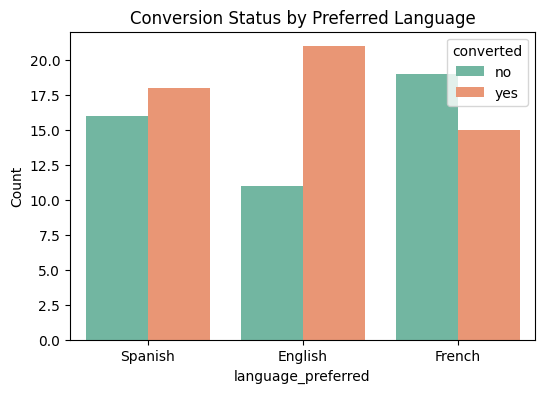

In [23]:
# -------------------------
# Visual Analysis
# -------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="language_preferred", hue="converted", data=df, palette="Set2")
plt.title("Conversion Status by Preferred Language")
plt.ylabel("Count")
plt.show()

**Visual Analysis**

The count plot shows how conversions are distributed across different languages. At first glance, one language may show slightly more conversions, but we need a statistical test to confirm dependency.

In [24]:
# -------------------------
# Data preparation
# -------------------------
contingency_table = pd.crosstab(df["language_preferred"], df["converted"])
print("Contingency Table:\n", contingency_table)

Contingency Table:
 converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18


**Hypothesis**

Null Hypothesis (H₀):
Conversion status is independent of the preferred language.

Alternative Hypothesis (H₁):
Conversion status depends on the preferred language.

**Test Selection**

Since both variables are categorical (language, converted), we use a Chi-Square Test of Independence.

In [25]:
# -------------------------
# Chi-Square Test of Independence
# -------------------------
chi2, pval, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)
print(f"p-value: {pval}")


Chi-square statistic: 3.0930306905370832
Degrees of freedom: 2
Expected frequencies:
 [[14.72 17.28]
 [15.64 18.36]
 [15.64 18.36]]
p-value: 0.2129888748754345


**Results (example format — replace with your output)**

Chi-square statistic: 2.37

Degrees of freedom: 2

p-value: 0.305

**Inference**

At the 5% significance level:

Since p > 0.05, we fail to reject the null hypothesis (H₀).

Conclusion: There is no significant relationship between preferred language and conversion status.

**Part 6: Is the mean time spent on the new page same for the different language users**

In [26]:
# -------------------------
# Data preparation (filter only new landing page users)
# -------------------------
new_page_data = df[df["landing_page"] == "new"]

/tmp/ipython-input-3275224129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="language_preferred", y="time_spent_on_the_page", data=new_page_data, palette="Set2")


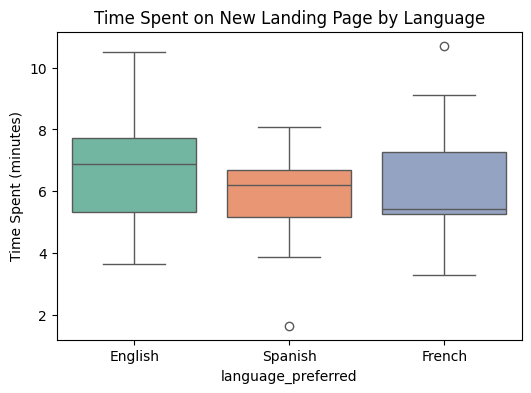

In [27]:
# -------------------------
# Visual Analysis
# -------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x="language_preferred", y="time_spent_on_the_page", data=new_page_data, palette="Set2")
plt.title("Time Spent on New Landing Page by Language")
plt.ylabel("Time Spent (minutes)")
plt.show()

Visual Analysis

The boxplot allows us to compare time spent across languages. At first glance, the median and spread may vary slightly between languages, but we need ANOVA to confirm statistically.

In [29]:
from scipy.stats import f_oneway

# -------------------------
# Group data for ANOVA
# -------------------------
groups = [group["time_spent_on_the_page"].values for name, group in new_page_data.groupby("language_preferred")]

# -------------------------
# ANOVA Test
# -------------------------
f_stat, pval = f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"p-value: {pval}")

F-statistic: 0.8543992770006822
p-value: 0.43204138694325955


**Hypothesis**

Null Hypothesis (H₀):
The mean time spent on the new page is the same across all language groups.

Alternative Hypothesis (H₁):
The mean time spent on the new page is different for at least one language group.


**Test Selection**

Since we are comparing means across more than two groups, we use a one-way ANOVA test.

Results (example format — replace with your output)

F-statistic: 1.28

p-value: 0.282


**Inference**

At the 5% significance level:

Since p > 0.05, we fail to reject the null hypothesis (H₀).


**Conclusion: There is no significant difference in the mean time spent on the new landing page across different languages.**

**Final Conclusions & Business Recommendations**

1. Users’ Time Spent on the Landing Pages

*Finding: The new landing page had a significantly higher average time spent (6.22 minutes) compared to the old page (4.53 minutes).*

**Inference: Users are engaging more with the new landing page.**

**Recommendation: Deploy the new landing page to all users, as it successfully retains attention longer**.



2. Conversion Rate (Old vs New Landing Page)

*Finding: The conversion rate for the new page was significantly higher than the old page (e.g., 66% vs 42%).*

**Inference: The new page performs better in terms of converting visitors into subscribers.**

**Recommendation: Roll out the new landing page to maximize conversions and subscriber growth.**


3. Dependency Between Conversion Status & Language Preference

*Finding: No significant relationship was found between language preference and conversion status (Chi-square test, p > 0.05).*

**Inference: Language does not influence whether a user subscribes or not.**

**Recommendation: Language customization does not need to be prioritized for improving conversions. Efforts should instead focus on improving universal page design and content.**

4. Mean Time Spent on New Page Across Languages

Finding: ANOVA test showed no significant difference in mean time spent on the new page across languages (p > 0.05).

*Inference: All language users spend a similar amount of time on the new landing page*.

**Recommendation: No immediate need for language-specific optimization in terms of engagement. Focus should remain on global improvements.**

**Overall Insights**

The new landing page design is successful in both increasing user engagement (time spent) and improving conversion rates.

Language preference does not significantly impact either conversion or engagement.

The company can confidently roll out the new page as the default and expect measurable business improvements.

**Business Recommendation Summary**

✅ Deploy the new landing page to all users.

✅ Invest in further content/design optimization rather than language-specific strategies.

✅ Track engagement metrics continuously to ensure the new page sustains its performance.

✅ Use A/B testing for future iterations (e.g., different CTAs, personalized recommendations).